In [1]:
# Importing the Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import pyplot

In [2]:
# load the dataset
df = pd.read_excel('BBDM Project.xlsx')

In [3]:
# Display the first few rows to explore the dataset
df.head()

,CRS,Torque,PRchd,Thrust,PRnet,Ground condition,RMC
0,7.0,330.0,9.73,2900.0,67.0,34,IV
1,7.0,335.0,9.80,3075.0,68.0,34,IV
2,7.0,334.5,9.70,3100.0,68.0,34,IV
3,7.0,300.0,10.00,3115.0,72.5,32,IV
4,7.2,305.0,11.00,2650.0,72.5,32,IV


## Step 1: General information about the dataset

In [5]:
# Step 1: General information about the dataset
# Data types, non-null counts
print("General Information:")
print(df.info()) 

General Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6879 entries, 0 to 6878
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CRS               6879 non-null   float64
 1   Torque            6879 non-null   float64
 2   PRchd             6879 non-null   float64
 3   Thrust            6879 non-null   float64
 4   PRnet             6879 non-null   float64
 5   Ground condition  6879 non-null   int64  
 6   RMC               6879 non-null   object 
dtypes: float64(5), int64(1), object(1)
memory usage: 376.3+ KB
None


In [6]:
 # Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())  


Missing Values:
CRS                 0
Torque              0
PRchd               0
Thrust              0
PRnet               0
Ground condition    0
RMC                 0
dtype: int64


In [7]:
# Unique values per column
print("\nUnique Values per Column:")
print(df.nunique())


Unique Values per Column:
CRS                   42
Torque               334
PRchd                147
Thrust              2328
PRnet                709
Ground condition      39
RMC                    3
dtype: int64


## Step 2: Descriptive statistics

In [9]:
df.describe().round(2)

,CRS,Torque,PRchd,Thrust,PRnet,Ground condition
count,6879.00,6879.00,6879.00,6879.00,6879.00,6879.00
mean,7.64,307.93,9.24,4964.85,69.84,37.36
std,0.89,55.60,2.11,1073.78,15.72,5.79
min,2.60,142.00,1.70,2059.00,13.00,14.00
25%,7.00,263.00,7.70,4200.00,58.10,35.00
50%,8.00,308.00,9.20,4866.00,69.10,37.00
75%,8.00,343.50,10.60,5700.00,81.10,41.00
max,9.50,546.00,17.10,11800.00,128.50,53.00


## Step 3: Pearson Correlation Analysis

In [11]:
# Keep only numeric columns for correlation
df_filtered = df.select_dtypes(include=[np.number])

# Triangle Correlation Heatmap
plt.figure(figsize=(12, 6), dpi=1200)
pyplot.rc('font', family='Arial')

# Compute the correlation matrix
corr_matrix = df_filtered.corr(numeric_only=True)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
np.fill_diagonal(mask, False)

# Custom annotation function
def annotate_heatmap(data, mask, fmt=".2f", **textkw):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if not mask[i, j]:
                plt.text(j + 0.5, i + 0.5, format(data[i, j], fmt), 
                         ha="center", va="center", **textkw)

# Plot the heatmap without built-in annotations
heatmap = sns.heatmap(corr_matrix, mask=mask, vmin=-1, vmax=1,
                      annot=False, cmap='coolwarm', square=True)

# Manually annotate the heatmap
annotate_heatmap(corr_matrix.values, mask, fmt='.2f', fontsize=12, color='black')

# Set title
plt.text(
    x=-0.15,
    y=1.03,
    s="",
    fontsize=16,
    fontweight='bold',
    transform=plt.gca().transAxes
)

# Customize axis labels
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, ha="right", size=12, color='black')
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0, size=12, color='black')

# Customize ticks
plt.tick_params(axis='x', which='both', bottom=True, color='black')
plt.tick_params(axis='y', which='both', left=True, color='black')

# Customize colorbar
cbar = heatmap.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(labelsize=12, colors='black')

# Save the figure
plt.savefig("Correlation Analysis for BBDM Project data.png", bbox_inches='tight')

# Show the plot
plt.show()

## Step 4: Visualisation with Box–Whisker and Violin Plot

In [13]:
# Define the column names, units, and colors
columns = ["CRS", "Torque", "PRchd", "Thrust", "PRnet", "Ground condition"]
colors = ["blue", "magenta", "teal", "orange", "green", "skyblue"]
units = ["[rpm]", "[kNm]", "[mm/rev]", "[kN]", "[mm/min]", "[RMR]"]


# Set font
plt.rcParams['font.family'] = 'Arial'

# Set up subplots as a 2x3 grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10), dpi=800)

# Flatten the 2D array of axes to make it easier to iterate through
axes = axes.flatten()

# Iterate through columns, units, and colors to create violin plots with box plots
for i, (column_name, unit, color) in enumerate(zip(columns, units, colors)):
    if i < len(axes):
        # Create a violin plot
        sns.violinplot(data=df[column_name], color=color, inner="quartiles", 
                       showfliers=False, showextrema=False, quantiles=[0.25, 0.5, 0.75], ax=axes[i])
        
        # Create a separate box plot on a second y-axis
        ax2 = axes[i].twinx()
        sns.boxplot(data=df[column_name], color="black", width=0.2, ax=ax2, 
                    boxprops=dict(facecolor='none', edgecolor='black'), medianprops=dict(color='red'))
        
        ax2.set_yticks([])  # Hide y-axis ticks for the box plot

        axes[i].set_title(column_name, fontsize=18)
        axes[i].set_ylabel(unit, fontsize=18)

        # Adjust the tick label size for both x and y axes
        axes[i].tick_params(axis='both', labelsize=18)

# Adjust layout and show the plots
plt.tight_layout()
plt.savefig('BBDM_Box–Whisker and Violin Plot.png', bbox_inches='tight')
plt.show()

## Step 5: Distribution with histograms

In [15]:
# Define the column names, units, and colors
columns = ["CRS", "Torque", "PRchd", "Thrust", "PRnet", "Ground condition"]
colors = ["blue", "magenta", "teal", "orange", "green", "skyblue"]
units = [" CRS [rpm]", "Torque [kNm]", "PRchd [mm/rev]", "Thrust [kN]", "PRnet [mm/min]", "Ground condition [RMR]"]


# Set font
plt.rcParams['font.family'] = 'Arial'

# Set the style for Seaborn
sns.set(style="white")

# Create subplots for each column
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10), dpi=800)

# Flatten the 2D array of subplots for easier indexing
axes = axes.flatten()

# Plot histograms
for i, column in enumerate(columns):
    sns.histplot(df[column], kde=True, color=colors[i], ax=axes[i], 
                 bins=20, line_kws={'color': 'red'})  # Change KDE line color to red
    axes[i].set_xlabel(units[i], fontsize=20, color='black')
    axes[i].set_ylabel('Frequency', fontsize=20, color='black')
    axes[i].tick_params(axis='both', which='major', labelsize=20, labelcolor='black')

# Adjust layout and save figure
plt.tight_layout()
plt.savefig('BBDM_Histograms.png', bbox_inches='tight')
plt.show()

C:\Programs\Anaconda3\2024.02\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Programs\Anaconda3\2024.02\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Programs\Anaconda3\2024.02\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Programs\Anaconda3\2024.02\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to 

## Step 6: Rock Mass Quality Class Visualisation

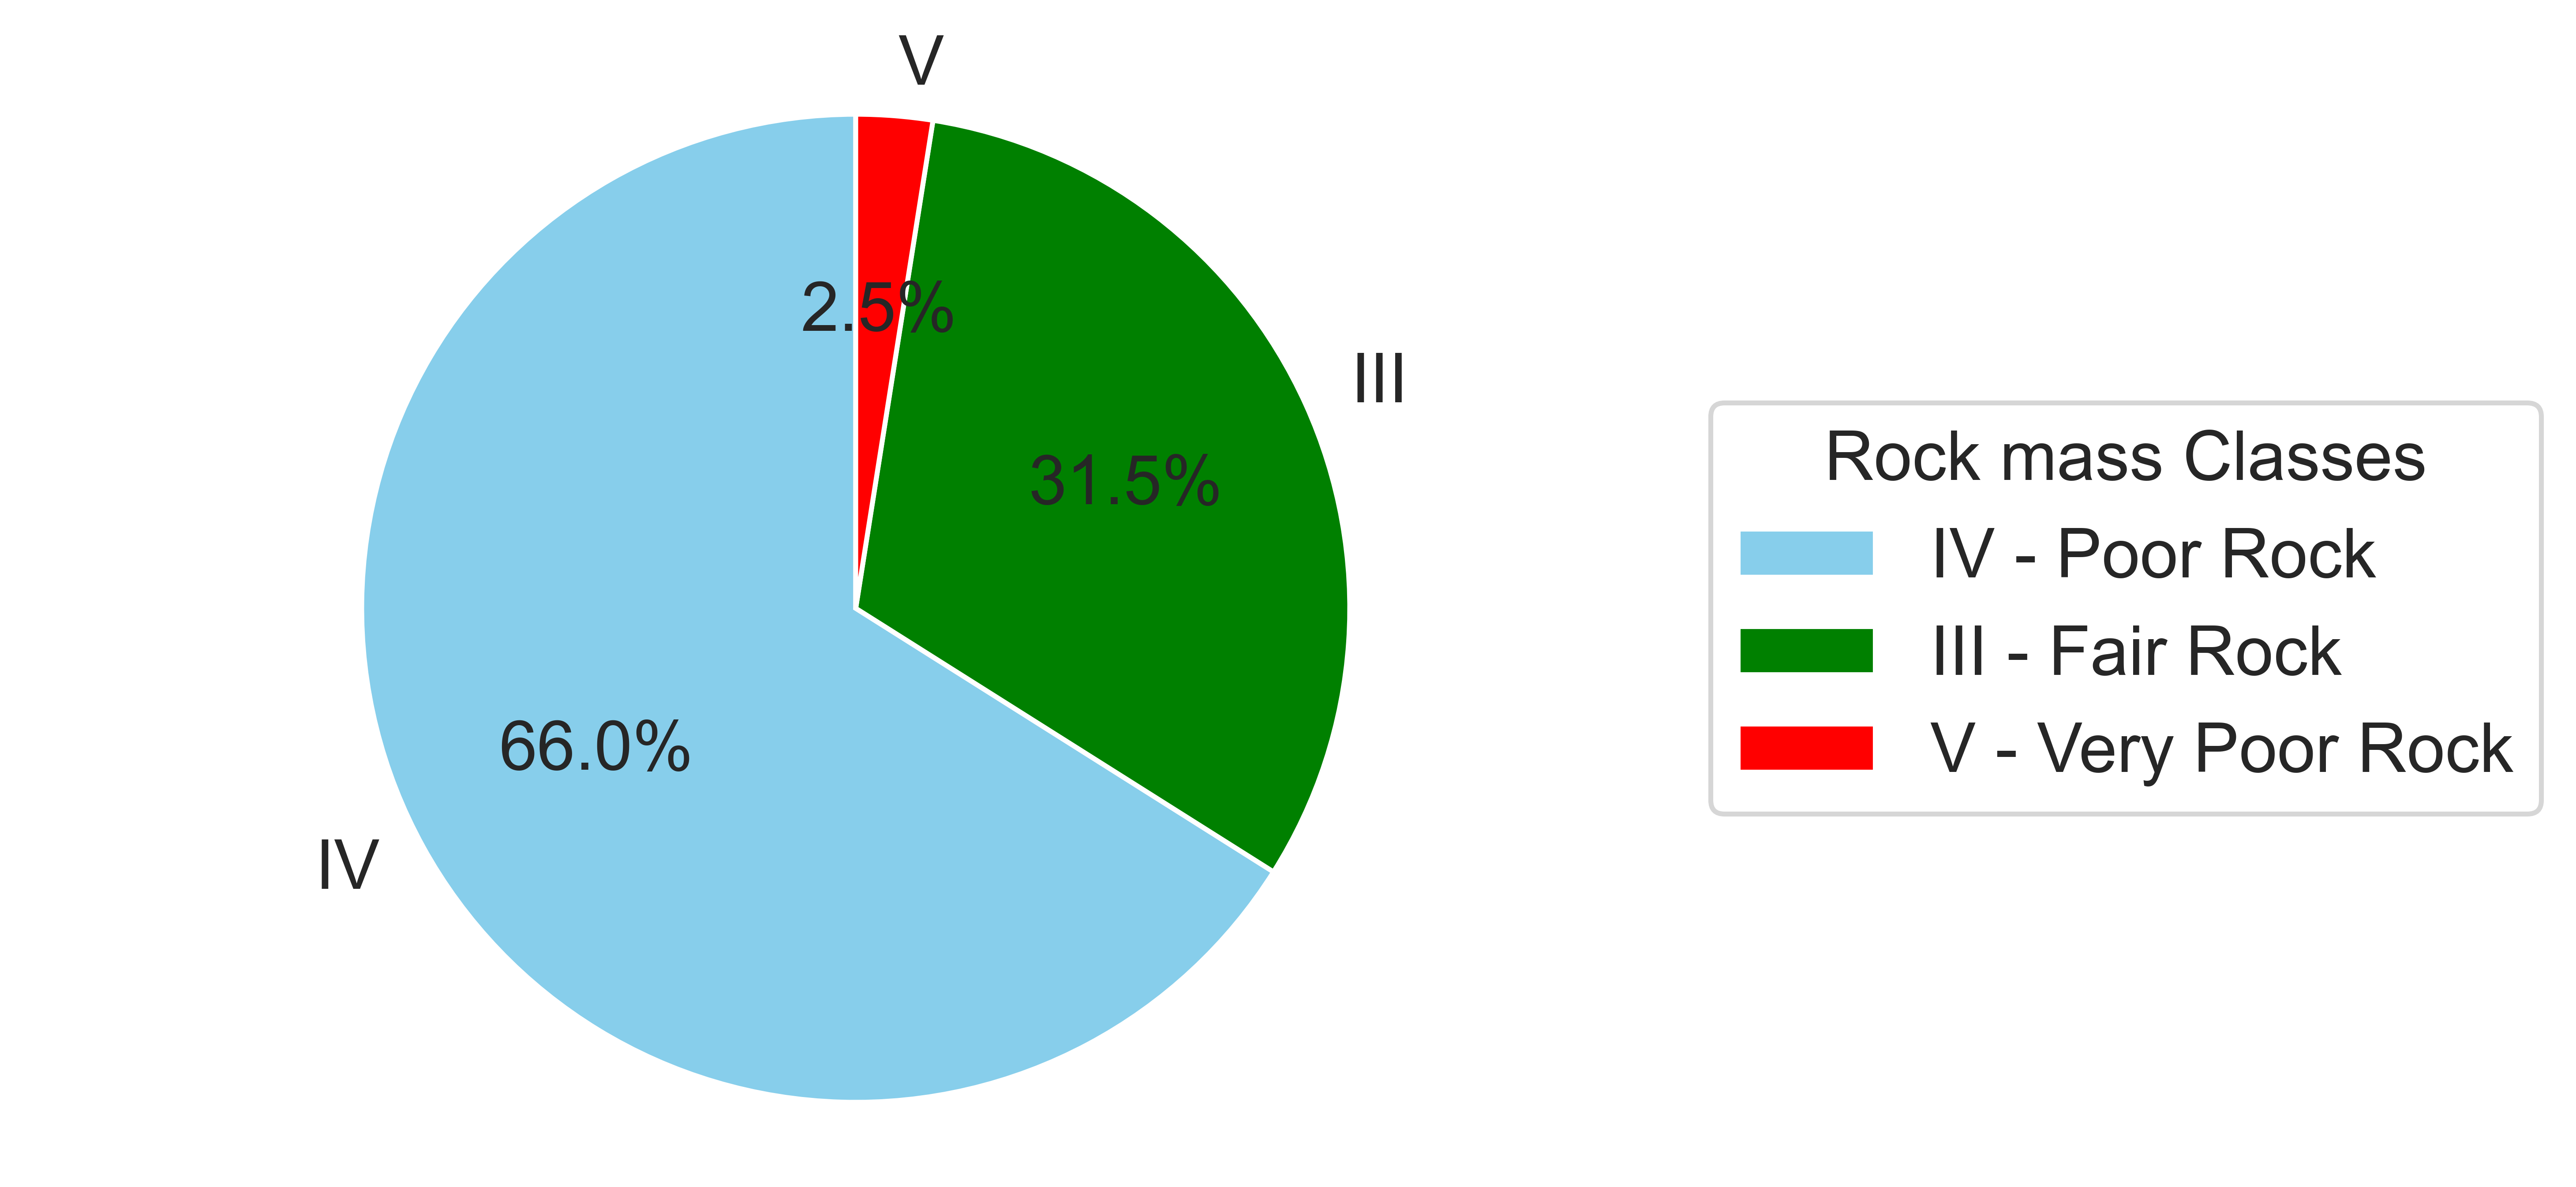

In [17]:
# Assuming your Excel sheet has a column named 'RMC'
class_counts = df['RMC'].value_counts()

# Calculate percentage for each class
class_percentages = (class_counts / class_counts.sum()) * 100

# Define the custom order and colors for RMC classes
custom_order = ['III', 'IV', 'V']
custom_colors = {'III': 'green', 'IV': 'skyblue', 'V': 'red'}

# Map your RMC classes to the desired legend labels
legend_labels = {'III': 'III - Fair Rock', 'IV': 'IV - Poor Rock', 'V': 'V - Very Poor Rock'}

# Set font
plt.rcParams['font.family'] = 'Arial'

# Set figure size
plt.figure(figsize=(6, 4), dpi=800)  # Adjust width and height as needed

# Plot pie chart
plt.pie(class_percentages, labels=class_percentages.index, autopct='%1.1f%%', startangle=90,
        colors=[custom_colors[key] for key in class_percentages.index], textprops={'fontsize': 14})
plt.axis('equal')  # Equal aspect ratio ensures pie is a circle

# Add legend
plt.legend([legend_labels[key] for key in class_percentages.index], 
           title="Rock mass Classes", loc="center left", bbox_to_anchor=(1, 0.5), 
           fontsize=14, title_fontsize=14)

# Save figure
plt.savefig('RMC_Class_Distribution.png', bbox_inches='tight')  # Save before plt.show()

# Display the pie chart
plt.show()
